# Feature engineering


In [1]:
import sys
sys.path.append("../../../src/ml")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyutils.pyplot import Plot
Plot(verbosity=0)

run = "k"

## Load data

In [2]:
from assemble import AssembleDataset
asm = AssembleDataset(run=run)
data = asm.assemble_dataset(n_outer_folds=5)

all_features = list(data["X"].columns)
print(f"Features ({len(all_features)}): {all_features}")

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
[Assemble] [OK] Prepared 5-fold nested CV (event-level grouping)
  Total: 2163528 coincidences
  Fold test sizes: [432706, 432706, 432706, 432705, 432705]
Features (9): ['crv_x', 'crv_y', 'crv_z', 'PEs', 'dT', 'nHits', 'nLayers', 'angle', 'sector']


In [3]:
# Baseline hyperparameters from optimisation
best_hp = {
    "n_estimators": 1000,
    "max_depth": 3,
    "learning_rate": 0.1,
    "device": "cuda",
    "tree_method": "hist"
}

In [4]:
from train import Train
from validate import Validate

## Feature importance 

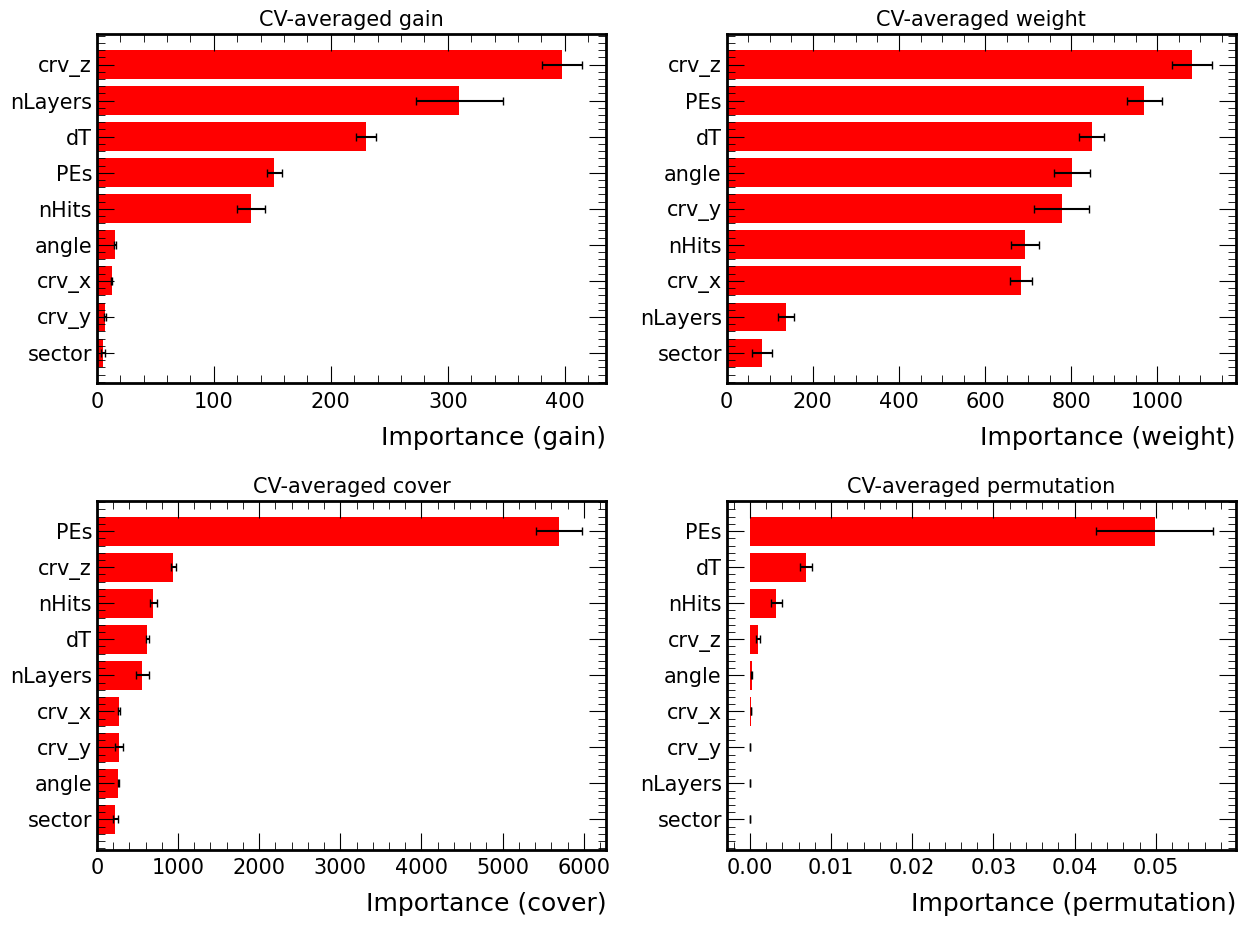

In [5]:
from sklearn.inspection import permutation_importance

X = data["X"].reset_index(drop=True)
y = data["y"].reset_index(drop=True)
metadata = data["metadata"].reset_index(drop=True)

# Use outer folds from assemble for consistency with train/optimise notebooks
folds = data["outer_folds"]

fold_importances = {"gain": [], "weight": [], "cover": [], "permutation": []}

for k, (train_idx, test_idx) in enumerate(folds):
    fold_data = {
        "X_train": X.iloc[train_idx], "X_test": X.iloc[test_idx],
        "y_train": y.iloc[train_idx], "y_test": y.iloc[test_idx],
        "metadata_train": metadata.iloc[train_idx], "metadata_test": metadata.iloc[test_idx],
    }
    trn = Train(fold_data, run=run, verbosity=0)
    results = trn.train(tag="cv_imp", save_output=False, **best_hp)

    booster = results["model"].get_booster()
    booster.feature_names = all_features
    for imp_type in ["gain", "weight", "cover"]:
        scores = booster.get_score(importance_type=imp_type)
        fold_importances[imp_type].append({f: scores.get(f, 0.0) for f in all_features})

    perm = permutation_importance(
        results["model"], X.iloc[test_idx], y.iloc[test_idx],
        scoring="roc_auc", n_repeats=10, random_state=42,
    )
    fold_importances["permutation"].append(dict(zip(all_features, perm.importances_mean)))

# Plot all four
fig, axes = plt.subplots(2, 2, figsize=(2*6.4, 2*4.8))

for ax, imp_type in zip(axes.flat, ["gain", "weight", "cover", "permutation"]):
    df = pd.DataFrame(fold_importances[imp_type])
    means = df.mean().sort_values()
    stds = df.std()[means.index]
    ax.barh(means.index, means.values, xerr=stds.values, capsize=3)
    ax.set_xlabel(f"Importance ({imp_type})")
    ax.set_title(f"CV-averaged {imp_type}")

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/cv_importance_all.png")
plt.show()

## Feature ablation

Drop one feature at a time and compare performance with the baseline (all features).

In [6]:
baseline_fold_aucs = []
baseline_fold_deadtimes = []

for k, (train_idx, test_idx) in enumerate(folds):
    fold_data = {
        "X_train": X.iloc[train_idx],
        "X_test": X.iloc[test_idx],
        "y_train": y.iloc[train_idx],
        "y_test": y.iloc[test_idx],
        "metadata_train": metadata.iloc[train_idx],
        "metadata_test": metadata.iloc[test_idx],
    }
    trn = Train(fold_data, run=run, verbosity=0)
    results = trn.train(tag=f"baseline_fold{k}", save_output=False, **best_hp)
    val = Validate(results, run=run, verbosity=0)
    val.roc_auc()
    thr = val.find_threshold(min_eff=0.999, plot=False, show=False)
    baseline_fold_aucs.append(val._test_auc)
    baseline_fold_deadtimes.append(thr["deadtime"] * 100)

baseline_auc = np.mean(baseline_fold_aucs)
baseline_dt = np.mean(baseline_fold_deadtimes)
print(f"CV baseline: test AUC={baseline_auc:.6f}, deadtime={baseline_dt:.3f}%")

CV baseline: test AUC=0.999889, deadtime=0.119%


In [7]:
ablation_fold_results = {feat: {"test_auc": [], "train_auc": [], "deadtime": []} for feat in all_features}

for k, (train_idx, test_idx) in enumerate(folds):
    for feat in all_features:
        reduced = [f for f in all_features if f != feat]
        fold_data = {
            "X_train": X[reduced].iloc[train_idx],
            "X_test": X[reduced].iloc[test_idx],
            "y_train": y.iloc[train_idx],
            "y_test": y.iloc[test_idx],
            "metadata_train": metadata.iloc[train_idx],
            "metadata_test": metadata.iloc[test_idx],
        }
        trn = Train(fold_data, run=run, verbosity=0)
        results = trn.train(tag=f"drop_{feat}_fold{k}", save_output=False, **best_hp)
        val = Validate(results, run=run, verbosity=0)
        val.roc_auc()
        thr = val.find_threshold(min_eff=0.999, plot=False, show=False)
        ablation_fold_results[feat]["test_auc"].append(val._test_auc)
        ablation_fold_results[feat]["train_auc"].append(val._train_auc)
        ablation_fold_results[feat]["deadtime"].append(thr["deadtime"] * 100)
    print(f"Fold {k} done")

# Build summary
ablation_cv = []
for feat in all_features:
    ablation_cv.append({
        "dropped": feat,
        "mean_test_auc": np.mean(ablation_fold_results[feat]["test_auc"]),
        "std_test_auc": np.std(ablation_fold_results[feat]["test_auc"]),
        "mean_train_auc": np.mean(ablation_fold_results[feat]["train_auc"]),
        "std_train_auc": np.std(ablation_fold_results[feat]["train_auc"]),
        "mean_deadtime": np.mean(ablation_fold_results[feat]["deadtime"]),
        "std_deadtime": np.std(ablation_fold_results[feat]["deadtime"]),
    })

ablation_cv_df = pd.DataFrame(ablation_cv).sort_values("mean_deadtime", ascending=True)
display(ablation_cv_df)

Fold 0 done
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done


,dropped,mean_test_auc,std_test_auc,mean_train_auc,std_train_auc,mean_deadtime,std_deadtime
8,sector,0.999893,0.000040,0.999984,0.000002,0.113243,0.063859
6,nLayers,0.999885,0.000050,0.999983,0.000002,0.146779,0.100415
5,nHits,0.999878,0.000052,0.999979,0.000001,0.167702,0.078571
0,crv_x,0.999889,0.000042,0.999983,0.000002,0.184124,0.123810
1,crv_y,0.999875,0.000047,0.999982,0.000001,0.215431,0.191307
7,angle,0.999883,0.000064,0.999980,0.000002,0.265561,0.131615
2,crv_z,0.999869,0.000046,0.999976,0.000002,0.366868,0.141340
3,PEs,0.999819,0.000069,0.999956,0.000002,0.768309,0.335294
4,dT,0.999659,0.000104,0.999903,0.000004,2.225684,1.401065


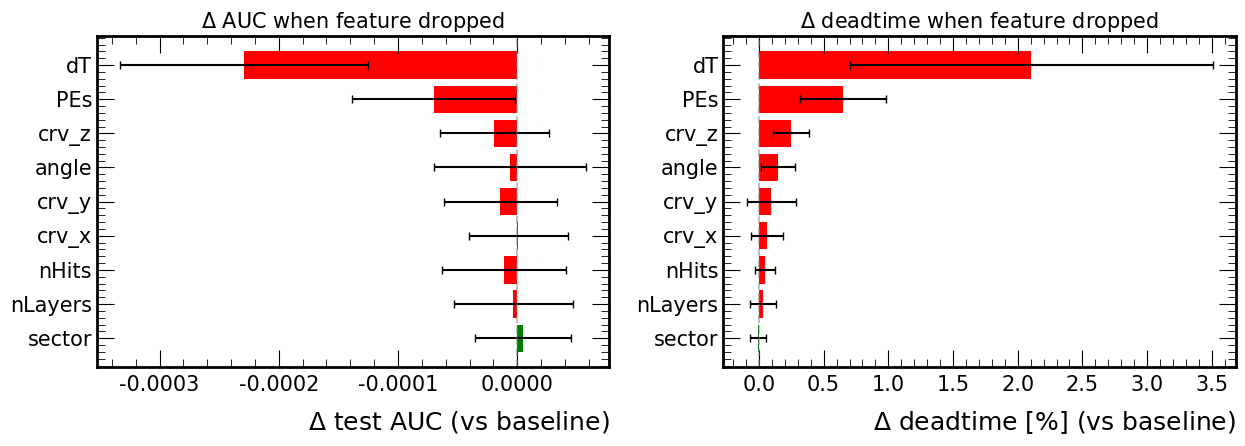

In [8]:
baseline_auc = np.mean(baseline_fold_aucs) 
baseline_dt = np.mean(baseline_fold_deadtimes)

features_sorted = ablation_cv_df["dropped"].values
delta_auc = ablation_cv_df["mean_test_auc"].values - baseline_auc
delta_deadtime = ablation_cv_df["mean_deadtime"].values - baseline_dt

fig, axes = plt.subplots(1, 2, figsize=(2*6.4, 4.8))

ax = axes[0]
colours = ["green" if d >= 0 else "red" for d in delta_auc]
ax.barh(features_sorted, delta_auc, xerr=ablation_cv_df["std_test_auc"].values,
        color=colours, capsize=3)
ax.axvline(0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("$\Delta$ test AUC (vs baseline)")
ax.set_title("$\Delta$ AUC when feature dropped")

ax = axes[1]
colours = ["green" if d <= 0 else "red" for d in delta_deadtime]
ax.barh(features_sorted, delta_deadtime, xerr=ablation_cv_df["std_deadtime"].values,
        color=colours, capsize=3)
ax.axvline(0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("$\Delta$ deadtime [%] (vs baseline)")
ax.set_title("$\Delta$ deadtime when feature dropped")

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/ablation_cv.png")
plt.show()


## Interesting plots

Deadtime: 

- dT and PEs are essential
- crv_z and angle have moderate impact
- others have negligible deadtime impact, their error bars overlap with zero
  
AUC

— sector actually improves things slightly when dropped 

## 2. L1 regularisation scan

Sweep `reg_alpha` and track feature importances. Features whose importance drops to ~0 at moderate L1 are candidates for removal.

In [9]:
alphas = [0, 0.1, 1, 5, 10, 50, 100]
importance_records = []
auc_records = []

for alpha in alphas:
    hp = {**best_hp, "reg_alpha": alpha}
    fold_importances = {feat: [] for feat in all_features}
    fold_aucs = []

    for k, (train_idx, test_idx) in enumerate(folds):
        fold_data = {
            "X_train": X.iloc[train_idx],
            "X_test": X.iloc[test_idx],
            "y_train": y.iloc[train_idx],
            "y_test": y.iloc[test_idx],
            "metadata_train": metadata.iloc[train_idx],
            "metadata_test": metadata.iloc[test_idx],
        }
        trn = Train(fold_data, run=run, verbosity=0)
        results = trn.train(tag=f"l1_alpha_{alpha}_fold{k}", save_output=False, **hp)

        booster = results["model"].get_booster()
        booster.feature_names = all_features
        importances = booster.get_score(importance_type="gain")
        for feat in all_features:
            fold_importances[feat].append(importances.get(feat, 0.0))

        val = Validate(results, run=run, verbosity=0)
        val.roc_auc()
        fold_aucs.append(val._test_auc)

    for feat in all_features:
        importance_records.append({
            "reg_alpha": alpha,
            "feature": feat,
            "importance_mean": np.mean(fold_importances[feat]),
            "importance_std": np.std(fold_importances[feat]),
        })

    auc_records.append({
        "reg_alpha": alpha,
        "test_auc_mean": np.mean(fold_aucs),
        "test_auc_std": np.std(fold_aucs),
    })
    print(f"  reg_alpha={alpha:>5}: test AUC={np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}")

l1_df = pd.DataFrame(importance_records)
l1_auc_df = pd.DataFrame(auc_records)

  reg_alpha=    0: test AUC=0.999889 ± 0.000044
  reg_alpha=  0.1: test AUC=0.999885 ± 0.000047
  reg_alpha=    1: test AUC=0.999895 ± 0.000043
  reg_alpha=    5: test AUC=0.999884 ± 0.000056
  reg_alpha=   10: test AUC=0.999874 ± 0.000042
  reg_alpha=   50: test AUC=0.999803 ± 0.000065
  reg_alpha=  100: test AUC=0.999647 ± 0.000133


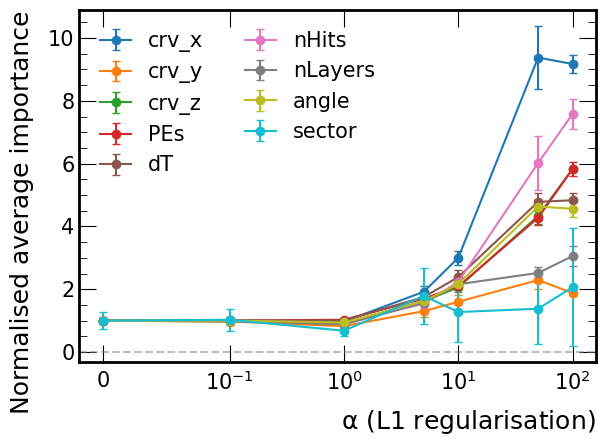

In [10]:
import matplotlib.cm as cm

colours = cm.tab10(np.linspace(0, 1, len(all_features)))

fig, ax = plt.subplots() # figsize=(, 5))

for i, feat in enumerate(all_features):
    feat_data = l1_df[l1_df["feature"] == feat]
    base_imp = feat_data[feat_data["reg_alpha"] == 0]["importance_mean"].values[0]
    if base_imp > 0:
        norm_mean = feat_data["importance_mean"].values / base_imp
        norm_std = feat_data["importance_std"].values / base_imp
    else:
        norm_mean = feat_data["importance_mean"].values
        norm_std = feat_data["importance_std"].values
    ax.errorbar(feat_data["reg_alpha"], norm_mean, yerr=norm_std,
                marker="o", label=feat, capsize=3, color=colours[i])

ax.set_xlabel(r"$\alpha$ (L1 regularisation)")
ax.set_xscale("symlog", linthresh=0.1)
ax.set_ylabel("Normalised average importance")
ax.legend(loc="upper left", ncols=2) # bbox_to_anchor=(1.05, 1), loc="upper left")
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/l1_importance_cv.png")
plt.show()


## Very interesting plot

L1 penalises the absolute value of leaf weights, which pushes small weights exactly to zero rather than just reducing them (L2). Features that contribute little have their weights zeroed out and the model stops splitting on them.

- sector is the only feature that gets suppressed by L1, drops to near zero at alpha=100; L1 is doing actual feature selection, confirming sector is the least useful feature.
- crv_y stays flat around 1, L1 doesn't penalise it but it doesn't grow either. Genuinely low importance.
  
Everything else increases with alph. As the model gets more constrained, the remaining splits need to extract more gain per feature, so the per-split gain goes up. It's an artefact of normalisation.

## Forward selection

In [11]:
# From permuation importance

# feature_order = ["PEs", "dT", "nHits", "crv_z", "angle", "crv_y", "nLayers", "crv_x", "sector"]
feature_order = ["PEs", "dT", "nHits", "crv_z", "angle", "crv_x", "crv_y", "nLayers", "sector"]

fold_deadtimes = []
fold_aucs = []
fold_train_aucs = []

for k, (train_idx, test_idx) in enumerate(folds):
    deadtimes_k = []
    aucs_k = []
    train_aucs_k = []
    for n in range(1, len(feature_order) + 1):
        features = feature_order[:n]
        fold_data = {
            "X_train": X[features].iloc[train_idx],
            "X_test": X[features].iloc[test_idx],
            "y_train": y.iloc[train_idx],
            "y_test": y.iloc[test_idx],
            "metadata_train": metadata.iloc[train_idx],
            "metadata_test": metadata.iloc[test_idx],
        }
        trn = Train(fold_data, run=run, verbosity=0)
        results = trn.train(tag=f"fwd_fold{k}_{n}", save_output=False, **best_hp)
        val = Validate(results, run=run, verbosity=0)
        val.roc_auc()
        thr = val.find_threshold(min_eff=0.999, plot=False, show=False)
        deadtimes_k.append(thr["deadtime"] * 100)
        aucs_k.append(val._test_auc)
        train_aucs_k.append(val._train_auc)
    fold_deadtimes.append(deadtimes_k)
    fold_aucs.append(aucs_k)
    fold_train_aucs.append(train_aucs_k)
    print(f"Fold {k} done")

Fold 0 done
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done


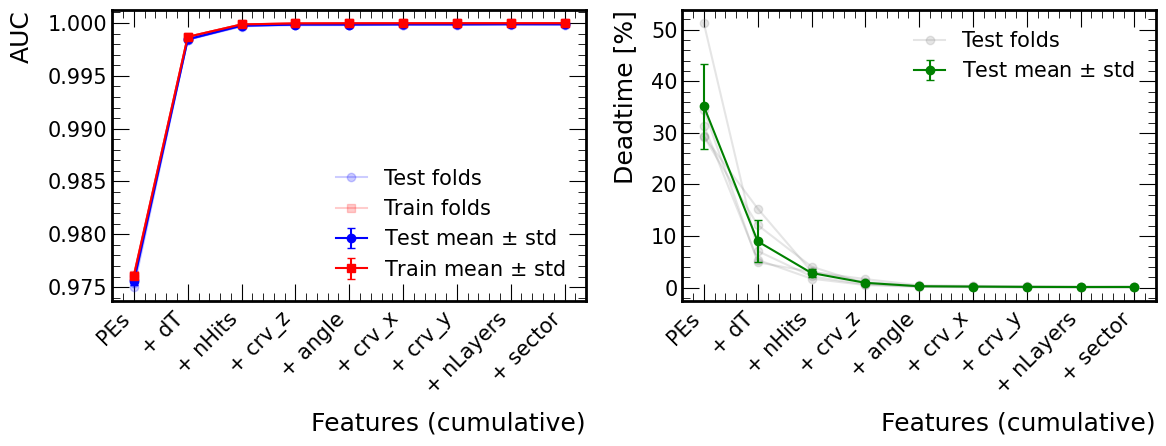

In [12]:
# Plot
xlabels = [feature_order[0]] + [f"+ {f}" for f in feature_order[1:]]
x = np.arange(1, len(feature_order) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# AUC panel — train and test
ax = axes[0]
for k in range(len(folds)):
    train_label=""
    test_label=""
    if k == 0:
        train_label="Train folds"
        test_label="Test folds"
    ax.plot(x, fold_aucs[k], "o-", alpha=0.2, color="blue", label=test_label)
    ax.plot(x, fold_train_aucs[k], "s-", alpha=0.2, color="red", label=train_label)
mean_test = np.mean(fold_aucs, axis=0)
std_test = np.std(fold_aucs, axis=0)
mean_train = np.mean(fold_train_aucs, axis=0)
std_train = np.std(fold_train_aucs, axis=0)
ax.errorbar(x, mean_test, yerr=std_test, fmt="o-", color="blue", capsize=3, label="Test mean $\pm$ std")
ax.errorbar(x, mean_train, yerr=std_train, fmt="s-", color="red", capsize=3, label="Train mean $\pm$ std")

ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("AUC")
ax.set_xlabel("Features (cumulative)")
ax.legend(loc="best")

# Deadtime panel
ax = axes[1]
for k in range(len(folds)):
    label=""
    if k == 0:
        label="Test folds"
    ax.plot(x, fold_deadtimes[k], "o-", alpha=0.2, color="grey", label=label)
mean_dt = np.mean(fold_deadtimes, axis=0)
std_dt = np.std(fold_deadtimes, axis=0)
ax.errorbar(x, mean_dt, yerr=std_dt, fmt="o-", color="green", capsize=3, label="Test mean $\pm$ std")
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("Deadtime [%]")
ax.set_xlabel("Features (cumulative)")
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/forward_selection_cv.png")
plt.show()

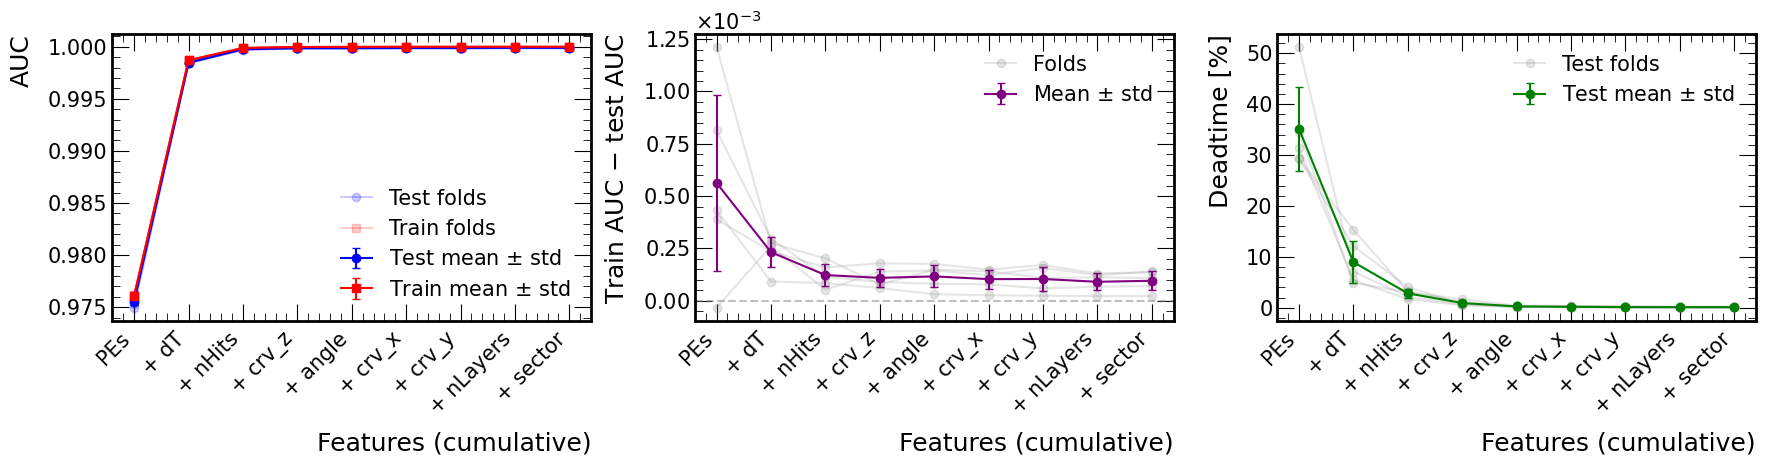

In [13]:
xlabels = [feature_order[0]] + [f"+ {f}" for f in feature_order[1:]]
x = np.arange(1, len(feature_order) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC panel — train and test
ax = axes[0]
for k in range(len(folds)):
    train_label=""
    test_label=""
    if k == 0:
        train_label="Train folds"
        test_label="Test folds"
    ax.plot(x, fold_aucs[k], "o-", alpha=0.2, color="blue", label=test_label)
    ax.plot(x, fold_train_aucs[k], "s-", alpha=0.2, color="red", label=train_label)
mean_test = np.mean(fold_aucs, axis=0)
std_test = np.std(fold_aucs, axis=0)
mean_train = np.mean(fold_train_aucs, axis=0)
std_train = np.std(fold_train_aucs, axis=0)
ax.errorbar(x, mean_test, yerr=std_test, fmt="o-", color="blue", capsize=3, label="Test mean $\pm$ std")
ax.errorbar(x, mean_train, yerr=std_train, fmt="s-", color="red", capsize=3, label="Train mean $\pm$ std")
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("AUC")
ax.set_xlabel("Features (cumulative)")
ax.legend(loc="best")

# Overfit gap panel
ax = axes[1]
fold_gaps = np.array(fold_train_aucs) - np.array(fold_aucs)
for k in range(len(folds)):
    label=""
    if k == 0:
        label="Folds"
    ax.plot(x, fold_gaps[k], "o-", alpha=0.2, color="grey", label=label)
mean_gap = np.mean(fold_gaps, axis=0)
std_gap = np.std(fold_gaps, axis=0)
ax.errorbar(x, mean_gap, yerr=std_gap, fmt="o-", color="purple", capsize=3, label="Mean $\pm$ std")
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)
ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0), useMathText=True)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("Train AUC $-$ test AUC")
ax.set_xlabel("Features (cumulative)")
ax.legend(loc="best")

# Deadtime panel
ax = axes[2]
for k in range(len(folds)):
    label=""
    if k == 0:
        label="Test folds"
    ax.plot(x, fold_deadtimes[k], "o-", alpha=0.2, color="grey", label=label)
mean_dt = np.mean(fold_deadtimes, axis=0)
std_dt = np.std(fold_deadtimes, axis=0)
ax.errorbar(x, mean_dt, yerr=std_dt, fmt="o-", color="green", capsize=3, label="Test mean $\pm$ std")
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_ylabel("Deadtime [%]")
ax.set_xlabel("Features (cumulative)")
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(f"../../../output/images/ml/{run}/features/forward_selection_cv.png")
plt.show()


In [14]:
pd.DataFrame({
    "features": [feature_order[0]] + [f"+ {f}" for f in feature_order[1:]],
    "n_features": range(1, len(feature_order) + 1),
    "mean_train_auc": mean_train,
    "std_train_auc": std_train,
    "mean_test_auc": mean_test,
    "std_test_auc": std_test,
    "mean_deadtime": mean_dt,
    "std_deadtime": std_dt,
})


,features,n_features,mean_train_auc,std_train_auc,mean_test_auc,std_test_auc,mean_deadtime,std_deadtime
0,PEs,1,0.976098,0.000077,0.975535,0.000348,35.157984,8.269605
1,+ dT,2,0.998693,0.000007,0.998462,0.000072,8.971119,4.079052
2,+ nHits,3,0.999871,0.000003,0.999749,0.000051,2.829368,0.812798
3,+ crv_z,4,0.999964,0.000002,0.999856,0.000043,0.931047,0.415382
4,+ angle,5,0.999977,0.000002,0.999861,0.000052,0.264191,0.110024
5,+ crv_x,6,0.999980,0.000002,0.999878,0.000046,0.199696,0.100939
6,+ crv_y,7,0.999983,0.000002,0.999879,0.000055,0.139000,0.095477
7,+ nLayers,8,0.999984,0.000002,0.999893,0.000040,0.113243,0.063859
8,+ sector,9,0.999984,0.000002,0.999889,0.000044,0.119294,0.066426


In [15]:
# Class imbalance across folds
for k, (train_idx, test_idx) in enumerate(folds):
    y_test_fold = y.iloc[test_idx]
    print(f"Fold {k}: {len(test_idx)} samples, "
          f"class ratio = {y_test_fold.sum()}/{len(y_test_fold)} "
          f"({y_test_fold.mean()*100:.2f}%)")

Fold 0: 432706 samples, class ratio = 4692/432706 (1.08%)
Fold 1: 432706 samples, class ratio = 4797/432706 (1.11%)
Fold 2: 432706 samples, class ratio = 4806/432706 (1.11%)
Fold 3: 432705 samples, class ratio = 4684/432705 (1.08%)
Fold 4: 432705 samples, class ratio = 4748/432705 (1.10%)


## CRV-XY out of bounds

In [16]:
# CRY bounds
cry_x_min, cry_x_max = data["X"][data["y"]==1]["crv_x"].min(), data["X"][data["y"]==1]["crv_x"].max()
cry_y_min, cry_y_max = data["X"][data["y"]==1]["crv_y"].min(), data["X"][data["y"]==1]["crv_y"].max()
print(f"CRY x range: [{cry_x_min:.0f}, {cry_x_max:.0f}]")
print(f"CRY y range: [{cry_y_min:.0f}, {cry_y_max:.0f}]")

# CE Mix out of bounds
ce_x = data["X"][data["y"]==0]["crv_x"]
ce_y = data["X"][data["y"]==0]["crv_y"]
oob_x = ((ce_x < cry_x_min) | (ce_x > cry_x_max)).sum()
oob_y = ((ce_y < cry_y_min) | (ce_y > cry_y_max)).sum()
print(f"\nCE Mix out of CRY bounds:")
print(f"  crv_x: {oob_x}/{len(ce_x)} ({oob_x/len(ce_x)*100:.2f}%)")
print(f"  crv_y: {oob_y}/{len(ce_y)} ({oob_y/len(ce_y)*100:.2f}%)")

CRY x range: [-3270, 4359]
CRY y range: [-2282, 2898]

CE Mix out of CRY bounds:
  crv_x: 58505/2139801 (2.73%)
  crv_y: 19116/2139801 (0.89%)


In [17]:
ce = data["X"][data["y"]==0]
oob_mask = (ce["crv_x"] < cry_x_min) | (ce["crv_x"] > cry_x_max)

print(f"Median PEs (in bounds):  {ce[~oob_mask]['PEs'].median():.0f}")
print(f"Median PEs (out of bounds): {ce[oob_mask]['PEs'].median():.0f}")
print(f"Median nHits (in bounds):  {ce[~oob_mask]['nHits'].median():.0f}")
print(f"Median nHits (out of bounds): {ce[oob_mask]['nHits'].median():.0f}")

Median PEs (in bounds):  220
Median PEs (out of bounds): 369
Median nHits (in bounds):  10
Median nHits (out of bounds): 17
